# Comparativa de modelos y elección final

Este notebook **no entrena nada**. Entrenar es trabajo de `python main.py`; aquí solo se
leen los resultados que dejó en `outputs/` y se cuentan.

Por qué separado: si el notebook entrenara por su cuenta tendrías dos verdades —la del
pipeline y la del notebook— y en la defensa te preguntarán cuál es la buena.

> Requisito: haber ejecutado antes `python main.py` (o `python main.py --demo`).

In [1]:
import sys, pathlib

# Subir hasta la raiz del proyecto (la carpeta que contiene src/), la abras desde donde la abras.
raiz = next(d for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (d / "src").is_dir())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

## 1. La tabla comparativa

Las seis filas con el mismo protocolo: mismo `StratifiedKFold`, misma semilla, el
preprocesado dentro del `Pipeline` y `scoring` fijado a la métrica principal.

In [2]:
tabla = pd.read_csv(config.OUTPUTS / "tabla_comparativa.csv")
display(tabla)

# La tabla del apartado 7 del README, con media ± desviación de los folds.
nombres = {"baseline": "Baseline (Dummy)", "logistica": "Regresión logística",
           "arbol": "Árbol de decisión", "bosque": "Random Forest",
           "boosting": "XGBoost", "red_keras": "Red neuronal (Keras)"}
es = lambda x: f"{x:.3f}".replace(".", ",")
readme = pd.DataFrame({"Modelo": tabla["modelo"].map(nombres)})
for metrica, titulo in [("f1", "F1 (CV)"), ("accuracy", "Accuracy"), ("precision", "Precision"),
                        ("recall", "Recall"), ("roc_auc", "ROC-AUC")]:
    readme[titulo] = [f"{es(m)} ± {es(s)}" for m, s in zip(tabla[metrica], tabla[f"{metrica}_std"])]
readme["Tiempo (s)"] = tabla["tiempo_s"].round().astype(int)
print(readme.to_markdown(index=False))  # para pegarla en el apartado 7 del README

,modelo,f1,f1_std,accuracy,accuracy_std,precision,precision_std,recall,recall_std,roc_auc,roc_auc_std,tiempo_s
0,boosting,0.6971,0.0067,0.8417,0.0032,0.7400,0.0060,0.6589,0.0081,0.9027,0.0042,100.4469
1,bosque,0.6927,0.0057,0.8407,0.0025,0.7419,0.0041,0.6497,0.0075,0.8977,0.0038,374.4495
2,red_keras,0.6691,0.0121,0.8324,0.0041,0.7359,0.0055,0.6138,0.0193,0.8908,0.0040,99.8483
3,arbol,0.6506,0.0031,0.8186,0.0023,0.6958,0.0079,0.6110,0.0060,0.8646,0.0057,13.1366
4,logistica,0.5419,0.0065,0.7860,0.0029,0.6633,0.0078,0.4581,0.0067,0.8307,0.0043,10.5970
5,baseline,0.0000,0.0000,0.7236,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,2.2317


| Modelo               | F1 (CV)       | Accuracy      | Precision     | Recall        | ROC-AUC       |   Tiempo (s) |
|:---------------------|:--------------|:--------------|:--------------|:--------------|:--------------|-------------:|
| XGBoost              | 0,697 ± 0,007 | 0,842 ± 0,003 | 0,740 ± 0,006 | 0,659 ± 0,008 | 0,903 ± 0,004 |          100 |
| Random Forest        | 0,693 ± 0,006 | 0,841 ± 0,003 | 0,742 ± 0,004 | 0,650 ± 0,007 | 0,898 ± 0,004 |          374 |
| Red neuronal (Keras) | 0,669 ± 0,012 | 0,832 ± 0,004 | 0,736 ± 0,005 | 0,614 ± 0,019 | 0,891 ± 0,004 |          100 |
| Árbol de decisión    | 0,651 ± 0,003 | 0,819 ± 0,002 | 0,696 ± 0,008 | 0,611 ± 0,006 | 0,865 ± 0,006 |           13 |
| Regresión logística  | 0,542 ± 0,006 | 0,786 ± 0,003 | 0,663 ± 0,008 | 0,458 ± 0,007 | 0,831 ± 0,004 |           11 |
| Baseline (Dummy)     | 0,000 ± 0,000 | 0,724 ± 0,000 | 0,000 ± 0,000 | 0,000 ± 0,000 | 0,500 ± 0,000 |            2 |


## 2. Por qué el baseline no es decorativo

`DummyClassifier` es la línea del suelo. Sin ella, un F1 de 0,80 no dice si tu modelo
aprendió algo o si el problema era fácil.

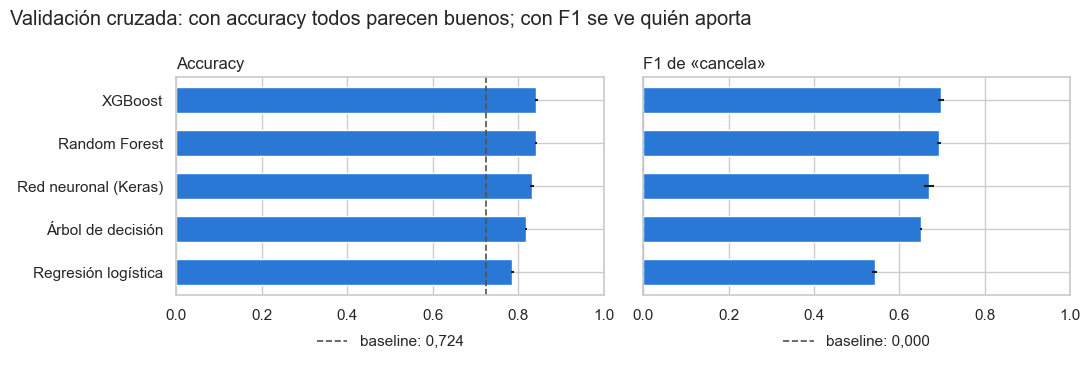

In [3]:
base = tabla.set_index("modelo").loc["baseline"]
orden = tabla.set_index("modelo").drop(index="baseline").sort_values("f1")

fig, (ax_acc, ax_f1) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, metrica, titulo in [(ax_acc, "accuracy", "Accuracy"), (ax_f1, "f1", "F1 de «cancela»")]:
    ax.barh(orden.index.map(nombres), orden[metrica], xerr=orden[f"{metrica}_std"],
            color="#2a78d6", height=0.6)
    ax.axvline(base[metrica], color="#52514e", ls="--", lw=1.2,
               label=f"baseline: {es(base[metrica])}")
    ax.set_title(titulo, loc="left")
    ax.set_xlim(0, 1)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
fig.suptitle("Validación cruzada: con accuracy todos parecen buenos; con F1 se ve quién aporta",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

## 3. Las tres figuras obligatorias

Ya las generó `evaluator.py`. Aquí se muestran juntas para poder narrarlas del tirón.

-- confusion_matrix.png --


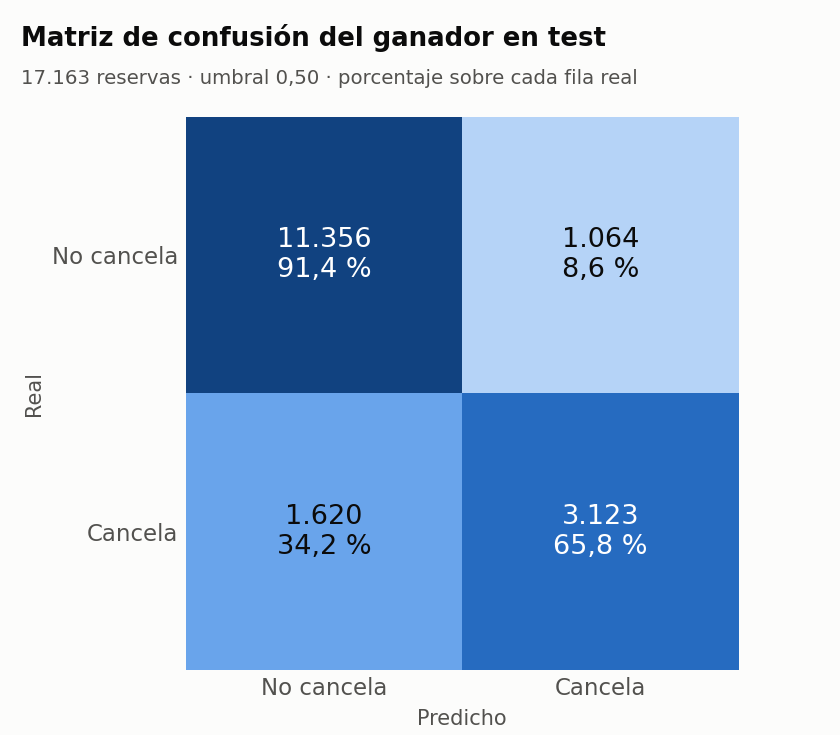

-- roc_curve.png --


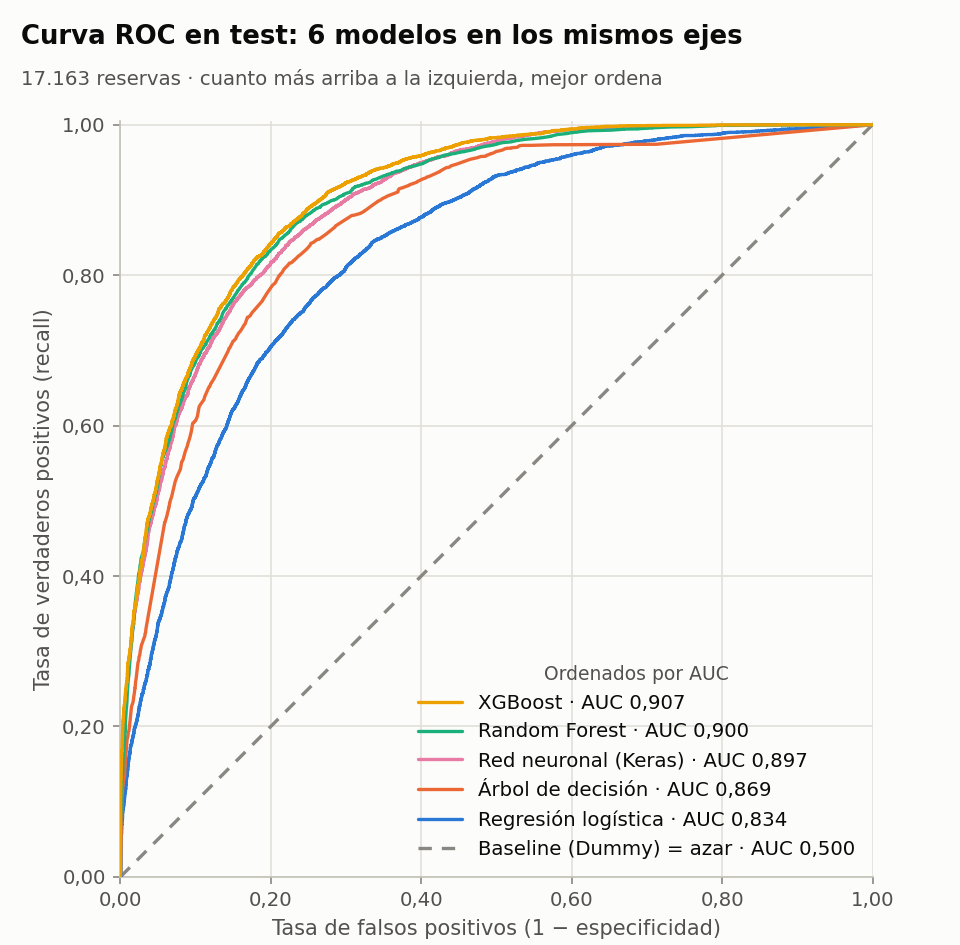

-- feature_importance.png --


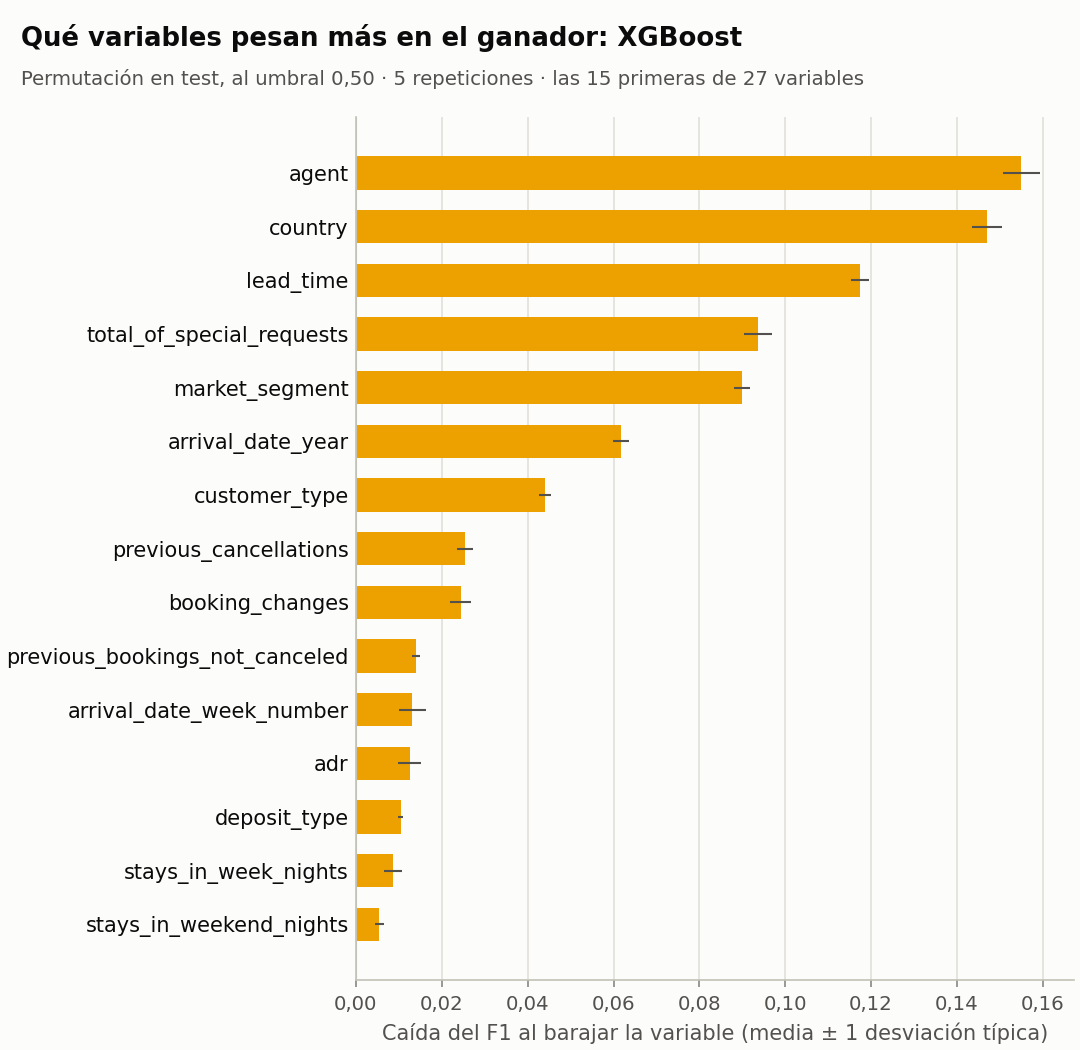

In [4]:
from IPython.display import Image, display as mostrar

for nombre in ["confusion_matrix.png", "roc_curve.png", "feature_importance.png"]:
    ruta = config.OUTPUTS / nombre
    print(f"-- {nombre} --")
    if ruta.exists():
        mostrar(Image(str(ruta)))
    else:
        print("   falta: ejecuta antes python main.py")

## 4. El ganador sobre el test

Medido **una sola vez**, al final. Cada vez que el test influye en una decisión deja de
ser una estimación honesta.

In [5]:
import json

metricas = json.loads((config.OUTPUTS / "metricas_test.json").read_text(encoding="utf-8"))
display(pd.Series(metricas).to_frame("valor"))

,valor
ganador,boosting
metrica_principal,f1
umbral,0.5
demo,False
f1,0.69944
accuracy,0.843617
precision,0.74588
recall,0.658444
roc_auc,0.906594
n,17163


## 5. Lectura: por qué gana este y no otro

**Modelo elegido:** XGBoost (`boosting`), con la combinación que eligió la búsqueda:
800 árboles, `learning_rate` 0,05, profundidad 8 y un 80 % de filas y columnas por árbol.

**Por qué gana:**

- **Es el mejor en la métrica principal y lo confirma el test.** F1 de 0,697 ± 0,007 en
  validación cruzada y 0,699 en test: el test no sale peor que la CV, así que no hay
  señal de haber elegido por suerte en los folds.
- **Frente al Random Forest**, que se queda muy cerca (0,693 y AUC 0,898 frente a
  0,903): gana en F1, recall, accuracy y AUC (el bosque solo es algo más preciso, 0,742
  frente a 0,740) y su búsqueda tardó menos (100 s frente a 374 s).
  Los dos son conjuntos de árboles; el boosting corrige en cada árbol los errores de los
  anteriores y afina mejor las reservas dudosas.
- **Frente a la logística** (0,542): la señal está en combinaciones —un `lead_time`
  largo pesa distinto según el agente o el segmento— y un modelo lineal sobre el one-hot
  no puede combinarlas. **Frente al árbol solo** (0,651): un árbol es una sola partición;
  cientos de ellos corrigiéndose se equivocan menos.
- **Frente a la red** (0,669 ± 0,012): con datos tabulares y categorías de alta
  cardinalidad, los árboles suelen ganar sin tanto ajuste; la red además varía más entre
  folds y es la más lenta de entrenar.

**Lo que no hace bien:** con el umbral de 0,50 deja escapar 1.620 de las 4.743
cancelaciones del test (recall 0,658): son habitaciones que se quedarán vacías sin
aviso. Mover el umbral cambiaría ese equilibrio, pero sin el coste real de cada error no
hay forma honesta de elegirlo (apartado 10 del README).